# Predictability Analysis: 6 README Stories

Comparing **Embedding Distance** and **Lexical Jaccard** as measures of how well generated endings converge to the actual ending as more of the story is revealed.

- **Low distance / high Jaccard** → model can predict the ending (low divergence)
- **Flat / high distance** → ending stays unpredictable (high divergence)


In [8]:
import json, os, re, warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

RESULTS_DIR  = "/project/jevans/maxzhuyt/narrative_project/results_scaled"
CORPUS_DIR   = "/project/jevans/maxzhuyt/narrative_project/NEWCORPUS_CLEANED"

README_STORIES = {
    "00066": ("Poor Girl",        "high"),
    "00135": ("Two Ruminations",  "moderate"),
    "00056": ("Snowing",          "low"),
    "00015": ("The Fellow",       "low"),
    "00144": ("Ladies' Lunch",    "high"),
    "00166": ("Martians",         "low"),
}

def split_sentences(text):
    """Same splitter as run_endings_scaled.py."""
    boundaries = [0]
    for m in re.finditer(r'[.!?]["\u201d\u2019)]*\s+(?=[A-Z\u201c"(\[])', text):
        boundaries.append(m.end())
    parts = []
    for i in range(len(boundaries)):
        start = boundaries[i]
        end = boundaries[i+1] if i+1 < len(boundaries) else len(text)
        s = text[start:end].strip()
        if s:
            parts.append(s)
    return parts

data = {}
for sid, (name, expected) in README_STORIES.items():
    fpath = os.path.join(RESULTS_DIR, f"{sid}_endings.json")
    if not os.path.exists(fpath):
        print(f"  {name}: NOT FOUND"); continue
    d = json.load(open(fpath))
    d["name"], d["expected"] = name, expected
    # Load and split the original story
    story_path = os.path.join(CORPUS_DIR, f"{sid}.txt")
    d["sentences"] = split_sentences(open(story_path).read())
    data[sid] = d
    print(f"  {name:25s} ({sid}): {d['n_sentences']} sents split, "
          f"{len(d['positions'])} positions")


  Poor Girl                 (00066): 102 sents split, 101 positions
  Two Ruminations           (00135): 32 sents split, 31 positions
  Snowing                   (00056): 217 sents split, 216 positions
  The Fellow                (00015): 214 sents split, 213 positions
  Ladies' Lunch             (00144): 253 sents split, 252 positions
  Martians                  (00166): 241 sents split, 240 positions


In [9]:
# ── Lexical Jaccard (vs. actual continuation from position i) ────────────────
# At position p, actual continuation = sentences[p:] joined.
# Mean Jaccard(ending, continuation) over all 100 endings.

def jaccard(a, b):
    sa, sb = set(a.lower().split()), set(b.lower().split())
    if not sa or not sb: return 0.0
    return len(sa & sb) / len(sa | sb)

lexical = {}
for sid, d in data.items():
    sentences = d["sentences"]
    pcts, scores = [], []
    for p in d["positions"]:
        pos = p["position"]                          # sentences revealed so far
        continuation = " ".join(sentences[pos:])     # everything after
        j = np.mean([jaccard(e, continuation) for e in p["endings"]])
        pcts.append(p["pct_story_revealed"])
        scores.append(j)
    lexical[sid] = (np.array(pcts), np.array(scores))

print("Lexical Jaccard computed.")
for sid, (pcts, scores) in lexical.items():
    print(f"  {data[sid]['name']:25s}: mean={scores.mean():.4f}, "
          f"early={scores[:5].mean():.4f}, late={scores[-5:].mean():.4f}")


Lexical Jaccard computed.
  Poor Girl                : mean=0.0359, early=0.0183, late=0.0762
  Two Ruminations          : mean=0.0405, early=0.0126, late=0.0815
  Snowing                  : mean=0.0248, early=0.0104, late=0.0509
  The Fellow               : mean=0.0277, early=0.0133, late=0.0245
  Ladies' Lunch            : mean=0.0256, early=0.0118, late=0.0739
  Martians                 : mean=0.0232, early=0.0089, late=0.1005


In [ ]:
# ── Load pre-computed embedding distances ─────────────────────────────────────
# Generated by compute_distances.sbatch (Qwen3-Embedding-0.6B, GPU).
# Format: {sid: {name, group, token_pcts, emb_distances}}

DISTANCES_FILE = "/project/jevans/maxzhuyt/narrative_project/distances/all_distances.json"

with open(DISTANCES_FILE) as f:
    _dist_data = json.load(f)

# Build emb_dist for the 6 literary stories: {sid: (pcts_array, scores_array)}
emb_dist = {
    sid: (np.array(v["token_pcts"]), np.array(v["emb_distances"]))
    for sid, v in _dist_data.items()
    if v["group"] == "literary"
}

# Build baseline_emb_dist: {sid: (pcts_array, scores_array)}
baseline_emb_dist = {
    sid: (np.array(v["token_pcts"]), np.array(v["emb_distances"]))
    for sid, v in _dist_data.items()
    if v["group"] == "baseline"
}

print(f"Loaded {len(emb_dist)} literary + {len(baseline_emb_dist)} baseline stories")
for sid, (p, s) in emb_dist.items():
    print(f"  [{sid}] {_dist_data[sid]['name']:35s}  {len(s)} positions")

In [ ]:
# emb_dist loaded from distances/all_distances.json above — no GPU needed here.

In [ ]:
# token_pcts already embedded in distances/all_distances.json — no patching needed.

In [20]:
# ── Peak-finding helpers & DeepSeek annotation generation ────────────────────
import os, asyncio
from openai import AsyncOpenAI

# Load API key from ~/.env
_env = {}
for _line in open(os.path.expanduser("~/.env")):
    _line = _line.strip()
    if "=" in _line and not _line.startswith("#"):
        _k, _v = _line.split("=", 1)
        _env[_k.strip()] = _v.strip()

_client = AsyncOpenAI(api_key=_env["DEEPSEEK_API_KEY"], base_url="https://api.deepseek.com")

def smooth(y, w=5):
    """Simple moving average."""
    if len(y) < w: return y
    return np.convolve(y, np.ones(w)/w, mode='same')

def find_top_peaks(y, n=3):
    """Return indices of top-n peaks ranked by prominence (no scipy)."""
    win   = max(5, len(y) // 10)
    peaks = []
    for i in range(1, len(y) - 1):
        if y[i] > y[i-1] and y[i] > y[i+1]:
            left_min  = min(y[max(0, i-win):i])
            right_min = min(y[i+1:min(len(y), i+win+1)])
            prominence = y[i] - max(left_min, right_min)
            peaks.append((prominence, i))
    peaks.sort(reverse=True)
    return sorted(p[1] for p in peaks[:n])   # back to positional order

async def _annotate(story_name, sentences, sent_pos):
    start   = max(0, sent_pos - 3)
    end     = min(len(sentences), sent_pos + 3)
    excerpt = " ".join(sentences[start:end])[:400]
    resp = await _client.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content":
             "You are a literary analyst. Given a short story excerpt, write a 3-6 word phrase "
             "describing the narrative moment (e.g. 'protagonist confronts her mother'). "
             "Output ONLY the phrase, no punctuation at the end."},
            {"role": "user", "content": f"Story: {story_name}\nExcerpt: {excerpt}"}
        ],
        max_tokens=25, temperature=0.3
    )
    return resp.choices[0].message.content.strip()

async def _compute_annotations():
    tasks, meta = [], []
    for sid, (pcts, scores) in emb_dist.items():
        y         = smooth(scores)
        peak_idxs = find_top_peaks(y, n=3)
        sentences = data[sid]["sentences"]
        positions = [p["position"] for p in data[sid]["positions"]]
        for k, pi in enumerate(peak_idxs):
            tasks.append(_annotate(data[sid]["name"], sentences, positions[pi]))
            meta.append((sid, float(pcts[pi]), float(y[pi])))

    labels = await asyncio.gather(*tasks)

    ANNOTATIONS = {sid: [] for sid in emb_dist}
    for (sid, pct, sy), label in zip(meta, labels):
        ANNOTATIONS[sid].append((pct, sy, label))
    return ANNOTATIONS

ANNOTATIONS = await _compute_annotations()

for sid, anns in ANNOTATIONS.items():
    print(f"\n{data[sid]['name']}:")
    for pct, sy, label in anns:
        print(f"  {pct:.0f}%  dist={sy:.3f}  → {label}")



Poor Girl:
  59%  dist=0.226  → father visits estranged daughter
  94%  dist=0.235  → grandmother awaits granddaughter's return
  96%  dist=0.237  → grandmother awaits granddaughter's return

Two Ruminations:
  7%  dist=0.244  → brother observes homeless man
  16%  dist=0.243  → man scavenges in trash cans
  98%  dist=0.208  → protagonist revisits past trauma

Snowing:
  74%  dist=0.219  → protagonist recalls childhood neighborhood
  77%  dist=0.222  → protagonist feels rebuked
  100%  dist=0.275  → laughter interrupts his joke

The Fellow:
  96%  dist=0.265  → protagonist urges departure
  97%  dist=0.329  → protagonist questions the fellow
  99%  dist=0.330  → protagonist receives a perfect description

Ladies' Lunch:
  59%  dist=0.225  → daughter insists on checking mother
  60%  dist=0.224  → family moves mother to smaller home
  97%  dist=0.235  → friends plan a visit

Martians:
  3%  dist=0.211  → senator's scandalous affair revealed
  28%  dist=0.229  → Senator demands Martian 

In [21]:
# ── Manual annotation override: The Fellow (00015) ───────────────────────────
# Peaks at ~65% and ~82% identified by close reading of the story text.

def peak_near(pcts, y, target, window=8):
    """Index of the highest smoothed value within ±window% of target."""
    mask = np.abs(pcts - target) <= window
    idx  = np.where(mask)[0]
    return idx[np.argmax(y[idx])] if len(idx) else np.argmin(np.abs(pcts - target))

sid = "00015"
pcts, scores = emb_dist[sid]
y = smooth(scores)

i65 = peak_near(pcts, y, 65)
i82 = peak_near(pcts, y, 82)

# Third peak: most prominent peak outside both regions
all_peaks = find_top_peaks(y, n=6)
thirds = [i for i in all_peaks if abs(pcts[i] - 65) > 8 and abs(pcts[i] - 82) > 8]
i3 = thirds[0] if thirds else all_peaks[0]

ANNOTATIONS["00015"] = sorted([
    (float(pcts[i3]),  float(y[i3]),  "creek floods, Philip unreachable"),
    (float(pcts[i65]), float(y[i65]), "talking dog recites guillotine poem"),
    (float(pcts[i82]), float(y[i82]), "Philip revealed deaf, stories lost"),
], key=lambda x: x[0])

print("The Fellow annotations:")
for pct, sy, label in ANNOTATIONS["00015"]:
    print(f"  {pct:.0f}%  dist={sy:.3f}  → {label}")


The Fellow annotations:
  64%  dist=0.244  → talking dog recites guillotine poem
  83%  dist=0.235  → Philip revealed deaf, stories lost
  96%  dist=0.265  → creek floods, Philip unreachable


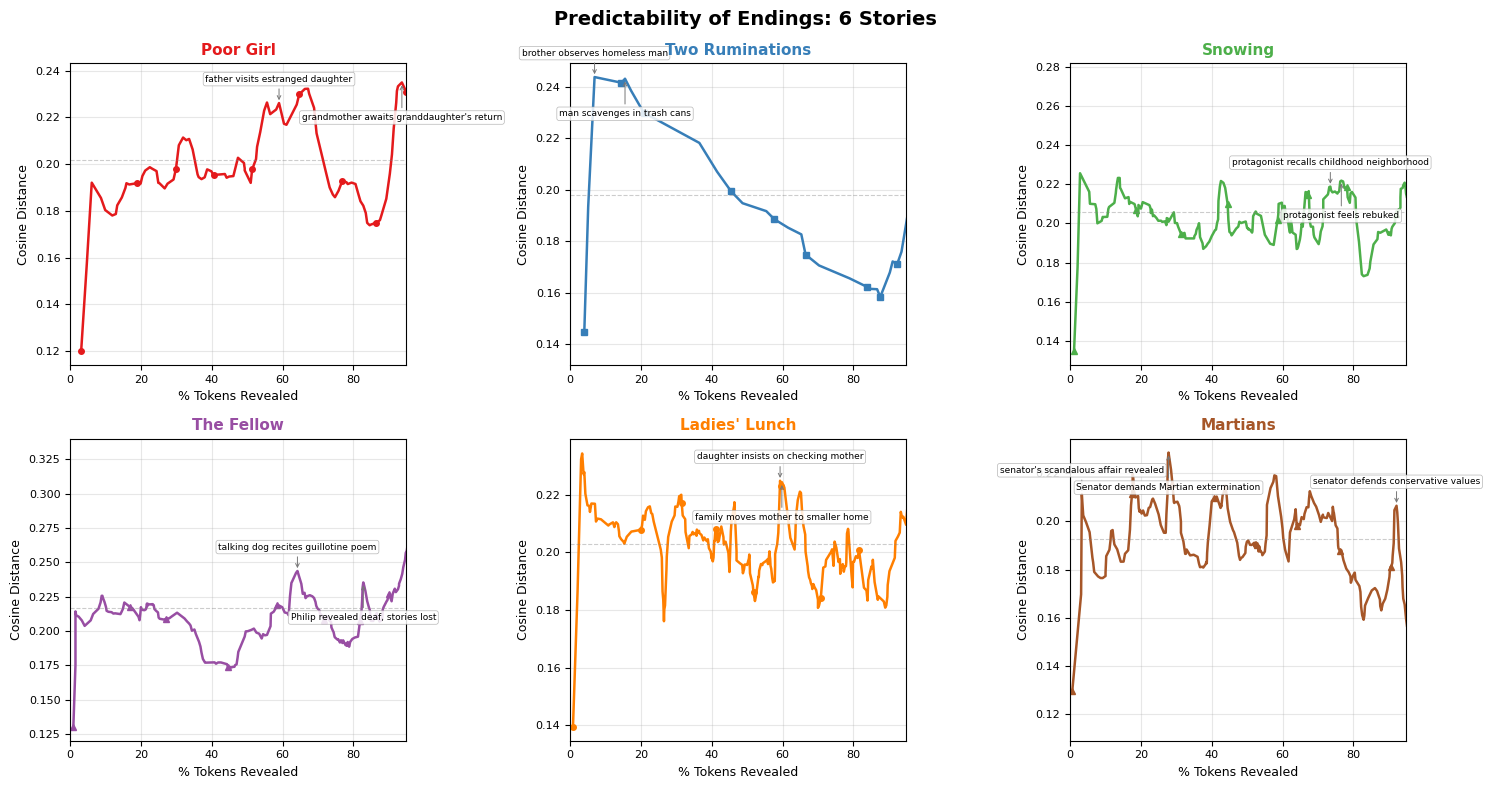

Saved → predictability_6stories.png


In [22]:
# ── 6-panel plot: one story per panel ────────────────────────────────────────
STORY_COLORS = {
    "00066": "#e41a1c",   # Poor Girl
    "00135": "#377eb8",   # Two Ruminations
    "00056": "#4daf4a",   # Snowing
    "00015": "#984ea3",   # The Fellow
    "00144": "#ff7f00",   # Ladies' Lunch
    "00166": "#a65628",   # Martians
}
MARKERS = {"high": "o", "moderate": "s", "low": "^"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Predictability of Endings: 6 Stories", fontsize=14, fontweight='bold')

for ax, (sid, (pcts, scores)) in zip(axes.flat, emb_dist.items()):
    name = data[sid]["name"]
    exp  = data[sid]["expected"]
    y    = smooth(scores)

    ax.plot(pcts, y, color=STORY_COLORS[sid], marker=MARKERS[exp],
            markevery=max(1, len(pcts)//8), markersize=4, linewidth=1.8)
    ax.set_title(name, fontsize=11, fontweight='bold', color=STORY_COLORS[sid])
    ax.set_xlabel("% Tokens Revealed", fontsize=9)
    ax.set_ylabel("Cosine Distance", fontsize=9)
    ax.set_xlim(0, 95)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)
    ax.axhline(y=np.mean(scores), color='gray', linestyle='--', linewidth=0.8, alpha=0.4)

    # ── Annotate 3 major peaks ───────────────────────────────────────────────
    offsets = [14, -22, 14]   # alternate above / below / above
    vas     = ['bottom', 'top', 'bottom']
    for i, (pct, sy, label) in enumerate(ANNOTATIONS[sid]):
        voff = offsets[i]
        ax.annotate(
            label,
            xy=(pct, sy),
            xytext=(0, voff), textcoords='offset points',
            fontsize=6.5, ha='center', va=vas[i],
            arrowprops=dict(arrowstyle='->', color='#777', lw=0.7),
            bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.85,
                      ec='#aaa', lw=0.5)
        )

plt.tight_layout()
plt.savefig("/project/jevans/maxzhuyt/narrative_project/predictability_6stories.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → predictability_6stories.png")


## Baseline Comparison

Results from `run_baseline_eval.sbatch` (H200 job). Loads b00XX stories from `BASELINE_CORPUS/results/` and compares against the 6 literary stories.

In [ ]:
BASELINE_RESULTS_DIR = "/project/jevans/maxzhuyt/narrative_project/BASELINE_CORPUS/results"
BASELINE_CORPUS_DIR  = "/project/jevans/maxzhuyt/narrative_project/BASELINE_CORPUS"

baseline_fnames = sorted(
    f for f in os.listdir(BASELINE_RESULTS_DIR)
    if f.endswith("_endings.json") and f.startswith("b")
)
if not baseline_fnames:
    print("No baseline results found — job still running?")
else:
    print(f"Found {len(baseline_fnames)} baseline stories")

baseline_data = {}
for fname in baseline_fnames:
    sid = fname.replace("_endings.json", "")
    d   = json.load(open(os.path.join(BASELINE_RESULTS_DIR, fname)))
    story_path = os.path.join(BASELINE_CORPUS_DIR, f"{sid}.txt")
    raw  = open(story_path).read()
    title = next(l.strip() for l in raw.splitlines() if l.strip())
    d["name"]      = title
    d["expected"]  = "baseline"
    d["sentences"] = split_sentences(raw)
    baseline_data[sid] = d
    print(f"  {title:40s} ({sid}): {d['n_sentences']} sents")

In [ ]:
# baseline_emb_dist loaded from distances/all_distances.json above — no GPU needed here.

In [ ]:
def summary(pcts, scores):
    y = smooth(scores)
    late = y[pcts >= 80] if (pcts >= 80).any() else y[-max(1, len(y)//5):]
    return dict(mean=float(np.mean(y)),
                peak=float(np.max(y)),
                late=float(np.mean(late)))

lit_rows  = [dict(sid=sid, name=data[sid]["name"],
                  **summary(pcts, scores))
             for sid, (pcts, scores) in emb_dist.items()]
base_rows = [dict(sid=sid, name=baseline_data[sid]["name"],
                  **summary(pcts, scores))
             for sid, (pcts, scores) in baseline_emb_dist.items()]

metrics       = ["mean", "peak", "late"]
metric_labels = ["Mean", "Peak", "Late(≥80%)"]

# ── Baseline distribution ────────────────────────────────────────────────────
print("BASELINE DISTRIBUTION  (n={})".format(len(base_rows)))
print(f"{'Metric':<14} {'min':>6} {'Q25':>6} {'med':>6} {'Q75':>6} {'max':>6} {'μ':>6} {'σ':>6}")
print("-" * 58)
for m, ml in zip(metrics, metric_labels):
    v = np.array([r[m] for r in base_rows])
    print(f"{ml:<14} {v.min():6.3f} {np.percentile(v,25):6.3f} "
          f"{np.median(v):6.3f} {np.percentile(v,75):6.3f} "
          f"{v.max():6.3f} {v.mean():6.3f} {v.std():6.3f}")

# ── Literary stories vs baseline ─────────────────────────────────────────────
print("\nLITERARY STORIES  (value | z-score vs baseline | percentile rank)")
for m, ml in zip(metrics, metric_labels):
    bv   = np.array([r[m] for r in base_rows])
    bmu, bsd = bv.mean(), bv.std()
    print(f"\n  {ml}")
    print(f"  {'Story':<28} {'val':>6}  {'z':>6}  {'pctile':>7}")
    print("  " + "-" * 50)
    for r in sorted(lit_rows, key=lambda x: -x[m]):
        val   = r[m]
        z     = (val - bmu) / bsd
        pctile = float(np.mean(bv < val)) * 100
        print(f"  {r['name']:<28} {val:6.3f}  {z:+6.2f}  {pctile:6.1f}%")